In [1]:
from sys import path
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in path:
    path.insert(0, str(ROOT))
    #print(f"Added {ROOT} to sys.path")


In [2]:
import pprint
import pandas as pd
from utils.dataset_transform import preprocess_splits
from utils.dataset_loader import get_dataset_path, load_dataset
from utils.dataset_preprocessor import to_spark_dfs, stop_spark_session, stratified_split_dataset

from spark_batch_trainer import CatBoostTrainer
from spark_batch_trainer import XGBoostTrainer
from spark_batch_trainer import LightGBMTrainer

from utils.visualize import (plot_confusion_matrices, plot_max_proba_distribution_px, 
                             plot_classwise_confidence_px,plot_calibration_curve_px
                            )




## Multiclass Dataset Preprocessing Pipeline

In [3]:
print("\n" + "="*60)
print("Load Multiclass Dataset")
print("="*60 + "\n")

dataset_path = get_dataset_path("data/multiclass_dataset")
df_multiclass = load_dataset(dataset_path)

print(f"Loaded dataset: {dataset_path.name}, shape = {df_multiclass.shape}")
display(df_multiclass.head())

print("\n" + "*"*60)
print("Performing stratified split into train, validation, and test sets")
print("*"*60 + "\n")

target_column = "NObeyesdad"

train_df, valid_df, test_df = stratified_split_dataset(
    df_multiclass,
    target_column=target_column,
    train_ratio=0.7,
    valid_ratio=0.15,
    test_ratio=0.15,
    shuffle=True,
    random_state=123,
)

print("\n" + "-"*60)
print("[Step] Preprocessing splits (includes Label Encoding of target)")
print("-"*60 + "\n")

# preprocessing + label encoding integrated
splits, encoder = preprocess_splits(
    train_df,
    valid_df,
    test_df,
    target_column=target_column,
    y_dtype="int",
    auto_encode_target=True,
)

print("Detected categorical columns:", splits.cat_cols)
print("Target classes:", encoder.classes_)
print("Encoded target example (train):", splits.y_train.unique())

# convenient unpacking
X_train, y_train = splits.X_train, splits.y_train
X_valid, y_valid = splits.X_valid, splits.y_valid
X_test,  y_test  = splits.X_test,  splits.y_test
cat_cols         = splits.cat_cols

print("\n" + "-"*60)
print("Converting pandas DataFrames to Spark DataFrames...")
print("-"*60 + "\n")

spark_train_df, spark_valid_df = to_spark_dfs(
    pd.concat([X_train, y_train], axis=1),
    pd.concat([X_valid, y_valid], axis=1),
)
print("Pandas DataFrames successfully converted to Spark DataFrames.")



Load Multiclass Dataset

Loaded dataset: ObesityDataset.csv, shape = (2111, 17)


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



************************************************************
Performing stratified split into train, validation, and test sets
************************************************************

Dataset split results:
 - Train set: (1477, 17) → 1477 samples, 7 distinct classes
 - Valid set: (317, 17) → 317 samples, 7 distinct classes
 - Test set : (317, 17) → 317 samples, 7 distinct classes

------------------------------------------------------------
[Step] Preprocessing splits (includes Label Encoding of target)
------------------------------------------------------------

Detected categorical columns: ['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight', 'CAEC', 'MTRANS']
Target classes: ['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']
Encoded target example (train): [5 3 2 4 6 0 1]

------------------------------------------------------------
Converting pandas DataFrames to Sp

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/09/26 10:44:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


[SPARK] Conversion successful → Spark DataFrames created.


[SPARK] Train rows: 1477 | Validation rows: 317
Pandas DataFrames successfully converted to Spark DataFrames.


## 1. Model - XGBoost

2025-09-26 10:45:12,982 - spark_batch_trainer.core.base_trainer - INFO - Validating input parameters
2025-09-26 10:45:12,985 - spark_batch_trainer.core.base_trainer - INFO - Validating input parameters...
2025-09-26 10:45:13,053 - spark_batch_trainer.core.base_trainer - INFO - Input parameters validation passed.
2025-09-26 10:45:13,054 - spark_batch_trainer.core.base_trainer - INFO - Preparing training data
2025-09-26 10:45:13,055 - spark_batch_trainer.core.base_trainer - INFO - Preparing validation data
2025-09-26 10:45:13,056 - spark_batch_trainer.core.base_trainer - INFO - Converting Spark DataFrame to pandas DataFrame for validation.


Importing XGBoostTrainer...
XGBoostTrainer instantiated successfully
===== Configuration XGBoost =====
{'objective': 'multi:softprob',
 'eval_metric': 'mlogloss',
 'n_estimators': 100,
 'max_depth': 6,
 'reg_lambda': 3.0,
 'subsample': 0.8,
 'colsample_bytree': 0.8,
 'random_state': 42,
 'early_stopping_rounds': 10}

===== Configuration Training =====
{'num_batches': 5,
 'max_patience': 2,
 'show_learning_curve': True,
 'use_sample_weight': True,
 'verbose': 100}

===== Configuration LR Scheduler =====
{'initial_lr': 0.1, 'decay_rate': 0.25, 'min_lr': 0.001}

Applying fit method...


2025-09-26 10:45:14,767 - spark_batch_trainer.core.base_trainer - INFO - Categorical features detected - Enabling categorical support for XGBoost model
2025-09-26 10:45:14,768 - spark_batch_trainer.core.memory_optimizer - INFO - === Starting memory optimization ===
2025-09-26 10:45:14,773 - spark_batch_trainer.core.memory_optimizer - INFO - Shape before optimization: (317, 16)
2025-09-26 10:45:14,774 - spark_batch_trainer.core.memory_optimizer - INFO - Shape after optimization:  (317, 16)
2025-09-26 10:45:14,775 - spark_batch_trainer.core.memory_optimizer - INFO - Memory before: 0.02 MB
2025-09-26 10:45:14,775 - spark_batch_trainer.core.memory_optimizer - INFO - Memory after:  0.01 MB
2025-09-26 10:45:14,776 - spark_batch_trainer.core.memory_optimizer - INFO - Memory reduced by: 0.01 MB
2025-09-26 10:45:14,777 - spark_batch_trainer.core.memory_optimizer - INFO - === Memory optimization finished ===
2025-09-26 10:45:14,777 - spark_batch_trainer.core.base_trainer - INFO - Setup training 

[0]	validation_0-mlogloss:1.78498	validation_1-mlogloss:1.81311
[99]	validation_0-mlogloss:0.07159	validation_1-mlogloss:0.43413


2025-09-26 10:45:19,181 - spark_batch_trainer.core.base_trainer - INFO - 🎯 Completed XGBoost training on batch 1
2025-09-26 10:45:19,182 - spark_batch_trainer.core.base_trainer - INFO - 🔍 Evaluating model on batch 1
2025-09-26 10:45:19,183 - spark_batch_trainer.core.base_trainer - INFO - Tracking evaluation metric: mlogloss
2025-09-26 10:45:19,184 - spark_batch_trainer.core.base_trainer - INFO - Batch 1 - mlogloss | Train: 0.07159 | Valid: 0.43413
2025-09-26 10:45:19,197 - spark_batch_trainer.core.base_trainer - INFO - 🎉 New best model - mlogloss: 0.43413 (improvement: inf)
2025-09-26 10:45:19,210 - spark_batch_trainer.core.base_trainer - INFO - Filtering batch 2/5
2025-09-26 10:45:19,251 - spark_batch_trainer.core.base_trainer - INFO - Converting Spark DataFrame to pandas DataFrame for batch 2/5
2025-09-26 10:45:20,978 - spark_batch_trainer.core.base_trainer - INFO -        
--- 📦 Processing batch 2/5 ---
2025-09-26 10:45:20,978 - spark_batch_trainer.core.base_trainer - INFO - Calcula

...

2025-09-26 10:45:24,647 - spark_batch_trainer.core.base_trainer - INFO - 🎯 Completed XGBoost training on batch 3
2025-09-26 10:45:24,648 - spark_batch_trainer.core.base_trainer - INFO - 🔍 Evaluating model on batch 3
2025-09-26 10:45:24,648 - spark_batch_trainer.core.base_trainer - INFO - Tracking evaluation metric: mlogloss
2025-09-26 10:45:24,648 - spark_batch_trainer.core.base_trainer - INFO - Batch 3 - mlogloss | Train: 0.23999 | Valid: 0.33053
2025-09-26 10:45:24,683 - spark_batch_trainer.core.base_trainer - INFO - 🎉 New best model - mlogloss: 0.33053 (improvement: 0.01216)
2025-09-26 10:45:24,718 - spark_batch_trainer.core.base_trainer - INFO - Filtering batch 4/5
2025-09-26 10:45:24,754 - spark_batch_trainer.core.base_trainer - INFO - Converting Spark DataFrame to pandas DataFrame for batch 4/5
2025-09-26 10:45:25,668 - spark_batch_trainer.core.base_trainer - INFO - 
--- 📦 Processing batch 4/5 ---
2025-09-26 10:45:25,668 - spark_batch_trainer.core.base_trainer - INFO - Calculatin

[0]	validation_0-mlogloss:0.28784	validation_1-mlogloss:0.32626
[99]	validation_0-mlogloss:0.27250	validation_1-mlogloss:0.32324


2025-09-26 10:45:26,528 - spark_batch_trainer.core.base_trainer - INFO - 🎯 Completed XGBoost training on batch 4
2025-09-26 10:45:26,528 - spark_batch_trainer.core.base_trainer - INFO - 🔍 Evaluating model on batch 4
2025-09-26 10:45:26,529 - spark_batch_trainer.core.base_trainer - INFO - Tracking evaluation metric: mlogloss
2025-09-26 10:45:26,529 - spark_batch_trainer.core.base_trainer - INFO - Batch 4 - mlogloss | Train: 0.27250 | Valid: 0.32324
2025-09-26 10:45:26,578 - spark_batch_trainer.core.base_trainer - INFO - 🎉 New best model - mlogloss: 0.32324 (improvement: 0.00729)
2025-09-26 10:45:26,623 - spark_batch_trainer.core.base_trainer - INFO - Filtering batch 5/5
2025-09-26 10:45:26,664 - spark_batch_trainer.core.base_trainer - INFO - Converting Spark DataFrame to pandas DataFrame for batch 5/5
2025-09-26 10:45:27,451 - spark_batch_trainer.core.base_trainer - INFO - 
--- 📦 Processing batch 5/5 ---
2025-09-26 10:45:27,452 - spark_batch_trainer.core.base_trainer - INFO - Calculatin

[0]	validation_0-mlogloss:0.35239	validation_1-mlogloss:0.34009
[99]	validation_0-mlogloss:0.34012	validation_1-mlogloss:0.33651


2025-09-26 10:45:28,615 - spark_batch_trainer.core.base_trainer - INFO - 🎯 Completed XGBoost training on batch 5
2025-09-26 10:45:28,615 - spark_batch_trainer.core.base_trainer - INFO - 🔍 Evaluating model on batch 5
2025-09-26 10:45:28,616 - spark_batch_trainer.core.base_trainer - INFO - Tracking evaluation metric: mlogloss
2025-09-26 10:45:28,617 - spark_batch_trainer.core.base_trainer - INFO - Batch 5 - mlogloss | Train: 0.34012 | Valid: 0.33651
2025-09-26 10:45:28,678 - spark_batch_trainer.core.base_trainer - INFO - ⏳ No improvement - Patience: 1/2
2025-09-26 10:45:28,679 - spark_batch_trainer.core.base_trainer - INFO - Cleaning cache of OptimizedWeightCalculator
2025-09-26 10:45:28,679 - spark_batch_trainer.core.base_trainer - INFO - Plotting learning-rate schedule (scheduler=Exponential Decay, n_points=5)


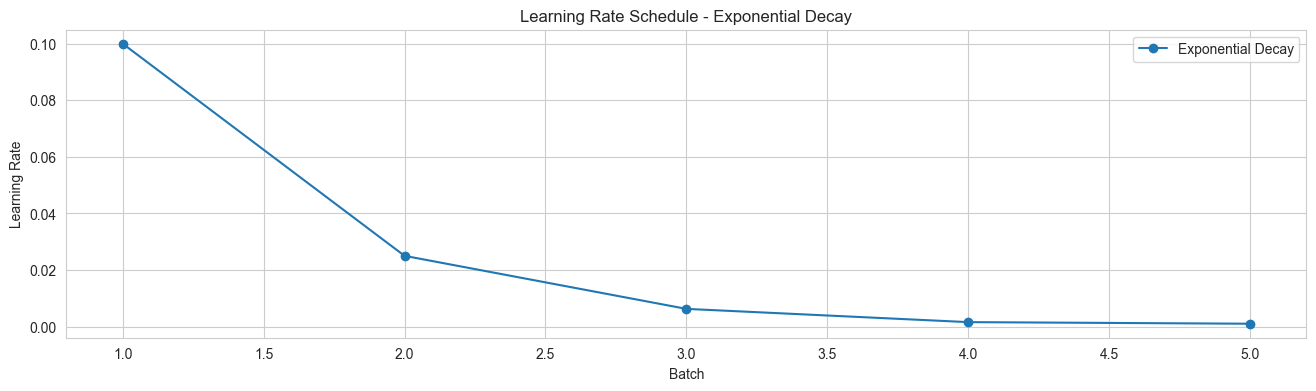

2025-09-26 10:45:28,919 - spark_batch_trainer.core.base_trainer - INFO - Plotting learning curve of XGBoost model...


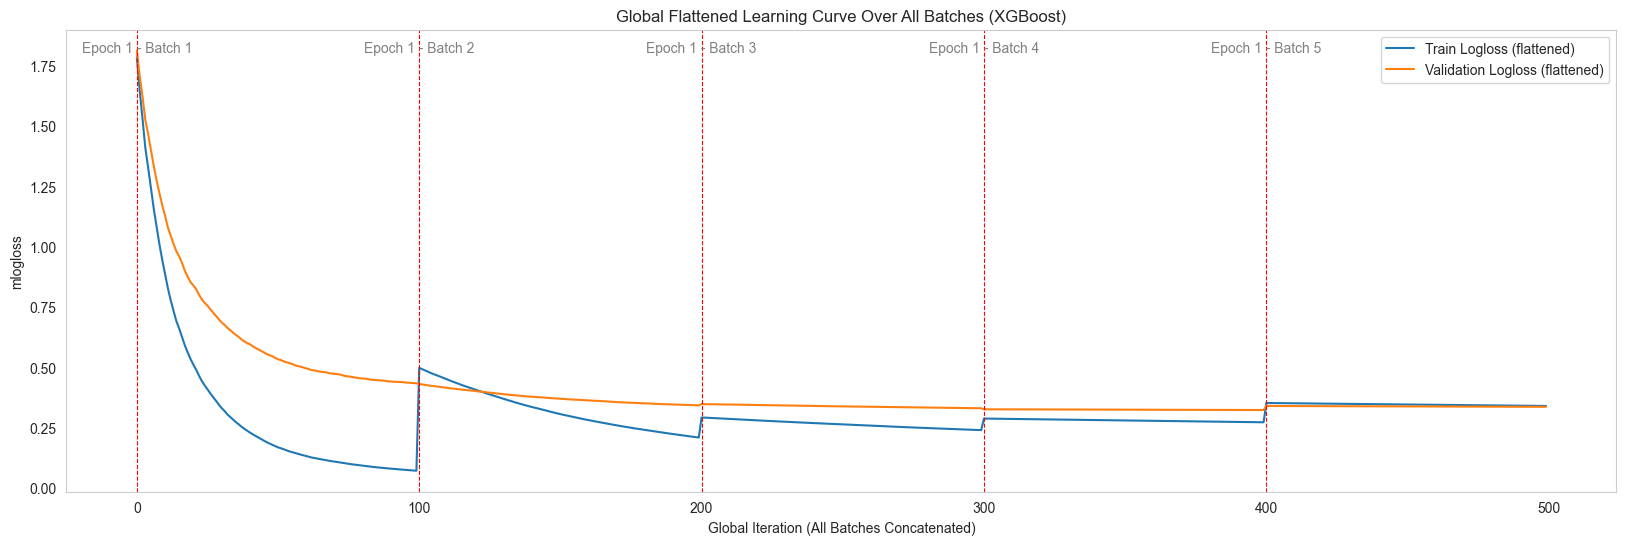

2025-09-26 10:45:29,049 - spark_batch_trainer.core.base_trainer - INFO - Learning curve plotted successfully.
2025-09-26 10:45:29,052 - spark_batch_trainer.core.base_trainer - INFO - XGBoost training completed
2025-09-26 10:45:29,052 - spark_batch_trainer.core.base_trainer - INFO - Total batches processed: 5
2025-09-26 10:45:29,053 - spark_batch_trainer.core.base_trainer - INFO - Best validation loss: 0.32324
2025-09-26 10:45:29,053 - spark_batch_trainer.core.base_trainer - INFO - Final model selected: best



   Evaluating the Trained Model



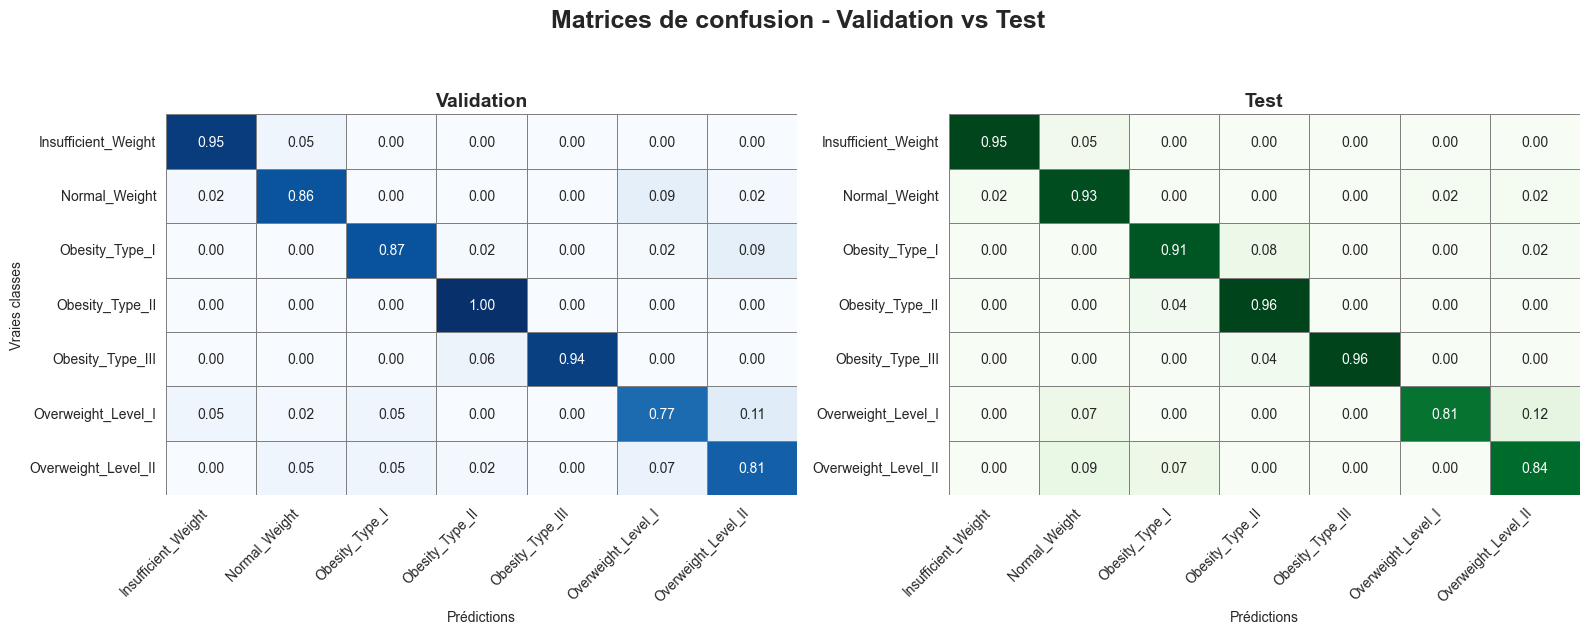

In [4]:
# ==================================================
# 1. Chargement & Configuration
# ==================================================
print("Importing XGBoostTrainer...")
trainer = XGBoostTrainer()
print("XGBoostTrainer instantiated successfully")

target_column = "NObeyesdad"

# Configuration modèle XGBoost (classification multiclasse)
config_model = {
    "objective": "multi:softprob",   # Classification multiclasse (probabilités)
    "eval_metric": "mlogloss",       # Log loss multiclasses
    "n_estimators": 100,             # Plus d’arbres (dataset plus complexe)
    "max_depth": 6,                  # Profondeur max
    "reg_lambda": 3.0,               # Régularisation L2
    "subsample": 0.8,                # Sous-échantillonnage des données
    "colsample_bytree": 0.8,         # Sous-échantillonnage des features
    "random_state": 42,              # Reproductibilité
    "early_stopping_rounds": 10,     # Early stopping sur validation
}

# Scheduler du learning rate
config_lr_scheduler = {
    "initial_lr": 0.1,
    "decay_rate": 0.25,
    "min_lr": 1e-3,
}

# Entraînement batch-wise
config_training = {
    "num_batches": 5,               # Nombre de lots
    "max_patience": 2,              # Patience early stopping global
    "show_learning_curve": True,    # Afficher la courbe d’apprentissage
    "use_sample_weight": True,      # Poids d’échantillons
    "verbose": 100,                 # Logs toutes les N itérations
}

print("===== Configuration XGBoost =====")
pprint.pprint(config_model, sort_dicts=False)
print("=================================\n")

print("===== Configuration Training =====")
pprint.pprint(config_training, sort_dicts=False)
print("=================================\n")

print("===== Configuration LR Scheduler =====")
pprint.pprint(config_lr_scheduler, sort_dicts=False)
print("=================================\n")


# ==================================================
# 2. Entraînement
# ==================================================
print("Applying fit method...")
trainer.fit(
    train_dataframe=spark_train_df,
    valid_dataframe=spark_valid_df,
    target_column=target_column,
    config_training=config_training,
    config_model=config_model,
    config_lr_scheduler=config_lr_scheduler,
)


# ==================================================
# 3. Évaluation
# ==================================================
print("\n" + "="*40)
print("   Evaluating the Trained Model")
print("="*40 + "\n")

# Récupération du modèle entraîné
final_model = trainer.get_trained_model()

# Prédictions
y_pred_valid = final_model.predict(X_valid)
y_pred_test  = final_model.predict(X_test)

# --------------------------------------------------
# Matrices de confusion
# --------------------------------------------------
plot_confusion_matrices(
    y_true_valid=y_valid,
    y_pred_valid=y_pred_valid,
    y_true_test=y_test,
    y_pred_test=y_pred_test,
    class_names=encoder.classes_,
    normalize=True   # Normaliser pour lecture en %
)

# --------------------------------------------------
# Probabilités & Confiance
# --------------------------------------------------
y_proba_valid = final_model.predict_proba(X_valid)
y_proba_test  = final_model.predict_proba(X_test)

# Histogramme des probabilités maximales
plot_max_proba_distribution_px(y_proba_valid, y_proba_test)

# Violin plot par classe
plot_classwise_confidence_px(
    y_proba_valid,
    y_proba_test,
    class_names=encoder.classes_
)

# Courbe de calibration
plot_calibration_curve_px(
    y_valid, y_proba_valid,
    y_test, y_proba_test
)


# 📊 Analyse des distributions de probabilités

---

## 1️⃣ Distribution des probabilités maximales (Histogramme bleu/orange)

👉 Ce graphe montre la **confiance globale du modèle** :

- La majorité des prédictions (Validation et Test) ont une **proba proche de 1.0** → ton modèle est **très confiant**.  
- La superposition des courbes bleu (**Validation**) et orange (**Test**) est **assez proche**, ce qui veut dire que ton modèle se comporte **de manière cohérente** sur les deux jeux de données.  
- Quelques prédictions ont des proba max autour de **0.5–0.7** → ce sont les cas où le modèle hésite, donc probablement les **erreurs de classification**.  

💡 **À retenir** : modèle confiant mais peut-être **trop confiant** → à vérifier avec la calibration.

---

## 2️⃣ Confiance par classe prédite (Boxplots bleu/orange)

👉 Ce graphe montre **comment la confiance varie par classe prédite** :

- Pour certaines classes (*Obesity_Type_III*, *Insufficient_Weight*), la distribution est **très concentrée vers 1** → le modèle est **quasi certain** de ses prédictions.  
- Pour d’autres classes (*Overweight_Level_II*, *Normal_Weight*), on observe une **variabilité plus forte** → le modèle est **moins sûr**, certaines prédictions sont faites avec des proba max < 0.8.  
- Les boxplots Validation (bleu) et Test (orange) se recouvrent bien → pas de gros décalage, ton modèle **généralise bien**.  

💡 **À retenir** : certaines classes sont **faciles à détecter** (forte confiance), d’autres plus **ambiguës** (risque de confusion).

---

## 3️⃣ Diagramme de calibration

👉 Ce graphe compare la **probabilité prédite** à la **fréquence réellement observée** :

- La ligne grise (diagonale) représente un modèle **parfaitement calibré** (ex : une prédiction de 0.7 = correcte 70% du temps).  
- Tes courbes Validation/Test montrent que :  
  - Le modèle est **assez bien calibré** quand la proba est haute (>0.7),  
  - Mais il a tendance à **sur-estimer la confiance** quand la proba est moyenne (0.4–0.6) → parfois il donne 60% de confiance, mais en réalité il est correct seulement 40–50% du temps.  
- Les courbes Validation et Test sont proches → **pas de surapprentissage évident**.  

💡 **À retenir** : ton modèle est globalement **bien calibré**, mais parfois **trop confiant** → un recalibrage (Platt scaling, isotonic regression) pourrait être envisagé.

---

## ✅ Synthèse

- Ton modèle est **très confiant** (probabilités proches de 1).  
- Certaines classes sont **plus difficiles à prédire** que d’autres.  
- La calibration est **bonne dans l’ensemble**, mais le modèle est parfois **trop confiant**.  


## 2. Model - Catboost

2025-09-26 10:46:28,766 - spark_batch_trainer.core.base_trainer - INFO - Validating input parameters
2025-09-26 10:46:28,769 - spark_batch_trainer.core.base_trainer - INFO - Validating input parameters...
2025-09-26 10:46:28,770 - spark_batch_trainer.core.base_trainer - INFO - Input parameters validation passed.
2025-09-26 10:46:28,771 - spark_batch_trainer.core.base_trainer - INFO - Preparing training data
2025-09-26 10:46:28,773 - spark_batch_trainer.core.base_trainer - INFO - Preparing validation data
2025-09-26 10:46:28,775 - spark_batch_trainer.core.base_trainer - INFO - Preparing validation data...
2025-09-26 10:46:28,777 - spark_batch_trainer.core.base_trainer - INFO - Converting Spark DataFrame to pandas DataFrame for validation.


Load Big MultiClass Dataset (Diabetes)
===== Configuration CatBoost =====
{'loss_function': 'MultiClass',
 'eval_metric': 'MultiClass',
 'iterations': 500,
 'learning_rate': 0.05,
 'depth': 6,
 'l2_leaf_reg': 3.0,
 'auto_class_weights': 'Balanced',
 'bootstrap_type': 'Bernoulli',
 'subsample': 0.8,
 'random_seed': 42,
 'verbose': 100}

===== Configuration Training =====
{'num_batches': 3, 'max_patience': 2, 'show_learning_curve': True}

Instantiating CatBoostTrainer...
Applying fit method...


2025-09-26 10:46:29,321 - spark_batch_trainer.core.base_trainer - INFO - Categorical features detected in validation set
2025-09-26 10:46:29,323 - spark_batch_trainer.core.base_trainer - INFO - Number of categorical features identified: 8
2025-09-26 10:46:29,325 - spark_batch_trainer.core.base_trainer - INFO - Sample weights for validation set computed successfully
2025-09-26 10:46:29,326 - spark_batch_trainer.core.memory_optimizer - INFO - === Starting memory optimization ===
2025-09-26 10:46:29,334 - spark_batch_trainer.core.memory_optimizer - INFO - Shape before optimization: (317, 16)
2025-09-26 10:46:29,336 - spark_batch_trainer.core.memory_optimizer - INFO - Shape after optimization:  (317, 16)
2025-09-26 10:46:29,336 - spark_batch_trainer.core.memory_optimizer - INFO - Memory before: 0.02 MB
2025-09-26 10:46:29,338 - spark_batch_trainer.core.memory_optimizer - INFO - Memory after:  0.01 MB
2025-09-26 10:46:29,339 - spark_batch_trainer.core.memory_optimizer - INFO - Memory reduce

0:	learn: 1.8680677	test: 1.8738297	best: 1.8738297 (0)	total: 84ms	remaining: 41.9s
100:	learn: 0.5849597	test: 0.6871770	best: 0.6871770 (100)	total: 1.76s	remaining: 6.97s
200:	learn: 0.2483564	test: 0.3920008	best: 0.3920008 (200)	total: 3.15s	remaining: 4.68s
300:	learn: 0.1457194	test: 0.2993459	best: 0.2993459 (300)	total: 4.37s	remaining: 2.89s
400:	learn: 0.1049788	test: 0.2657181	best: 0.2657181 (400)	total: 6.12s	remaining: 1.51s


2025-09-26 10:46:38,098 - spark_batch_trainer.core.base_trainer - INFO - Model trained on batch 1/3
2025-09-26 10:46:38,101 - spark_batch_trainer.core.base_trainer - INFO - Evaluating model performance on batch 1.
2025-09-26 10:46:38,106 - spark_batch_trainer.core.base_trainer - INFO - Tracking evaluation metric: MultiClass
2025-09-26 10:46:38,106 - spark_batch_trainer.core.base_trainer - INFO - Batch 1 - MultiClass | Train: 0.08119 | Valid: 0.24297
2025-09-26 10:46:38,109 - spark_batch_trainer.core.base_trainer - INFO - 🎉 New best model found - MultiClass: 0.24297 (improvement: inf)
2025-09-26 10:46:38,109 - spark_batch_trainer.core.base_trainer - INFO - Filtering batch 2/3
2025-09-26 10:46:38,185 - spark_batch_trainer.core.base_trainer - INFO - Converting Spark DataFrame to pandas DataFrame for batch 2/3


...

499:	learn: 0.0587626	test: 0.1882610	best: 0.1882610 (499)	total: 6.34s	remaining: 0us

bestTest = 0.1882610169
bestIteration = 499



2025-09-26 10:46:46,893 - spark_batch_trainer.core.base_trainer - INFO - 
--- 📦 Processing batch 3/3 ---
2025-09-26 10:46:46,894 - spark_batch_trainer.core.base_trainer - INFO - Calculating sample weights for batch 3
2025-09-26 10:46:46,895 - spark_batch_trainer.core.base_trainer - INFO - Converting all features of type 'object' to 'categorical'
2025-09-26 10:46:46,901 - spark_batch_trainer.core.memory_optimizer - INFO - === Starting memory optimization ===
2025-09-26 10:46:46,905 - spark_batch_trainer.core.memory_optimizer - INFO - Shape before optimization: (489, 16)
2025-09-26 10:46:46,905 - spark_batch_trainer.core.memory_optimizer - INFO - Shape after optimization:  (489, 16)
2025-09-26 10:46:46,906 - spark_batch_trainer.core.memory_optimizer - INFO - Memory before: 0.04 MB
2025-09-26 10:46:46,906 - spark_batch_trainer.core.memory_optimizer - INFO - Memory after:  0.02 MB
2025-09-26 10:46:46,907 - spark_batch_trainer.core.memory_optimizer - INFO - Memory reduced by: 0.01 MB
2025-0

0:	learn: 0.1968337	test: 0.1991952	best: 0.1991952 (0)	total: 8.01ms	remaining: 4s
100:	learn: 0.1476812	test: 0.1844999	best: 0.1844999 (100)	total: 1.1s	remaining: 4.36s
200:	learn: 0.1220041	test: 0.1776735	best: 0.1774849 (195)	total: 2.41s	remaining: 3.58s
300:	learn: 0.1073467	test: 0.1736161	best: 0.1736156 (299)	total: 3.73s	remaining: 2.47s
400:	learn: 0.0919047	test: 0.1690301	best: 0.1690301 (400)	total: 5.03s	remaining: 1.24s


2025-09-26 10:46:53,391 - spark_batch_trainer.core.base_trainer - INFO - Model trained on batch 3/3
2025-09-26 10:46:53,394 - spark_batch_trainer.core.base_trainer - INFO - Evaluating model performance on batch 3.
2025-09-26 10:46:53,401 - spark_batch_trainer.core.base_trainer - INFO - Tracking evaluation metric: MultiClass
2025-09-26 10:46:53,402 - spark_batch_trainer.core.base_trainer - INFO - Batch 3 - MultiClass | Train: 0.07789 | Valid: 0.16354
2025-09-26 10:46:53,407 - spark_batch_trainer.core.base_trainer - INFO - 🎉 New best model found - MultiClass: 0.16354 (improvement: 0.02472)
2025-09-26 10:46:53,409 - spark_batch_trainer.core.base_trainer - INFO - Clearing cache of OptimizedWeightCalculator
2025-09-26 10:46:53,410 - spark_batch_trainer.core.base_trainer - INFO - Plotting learning curve of CatBoost model...


499:	learn: 0.0778910	test: 0.1635364	best: 0.1635364 (499)	total: 6.36s	remaining: 0us

bestTest = 0.1635363927
bestIteration = 499



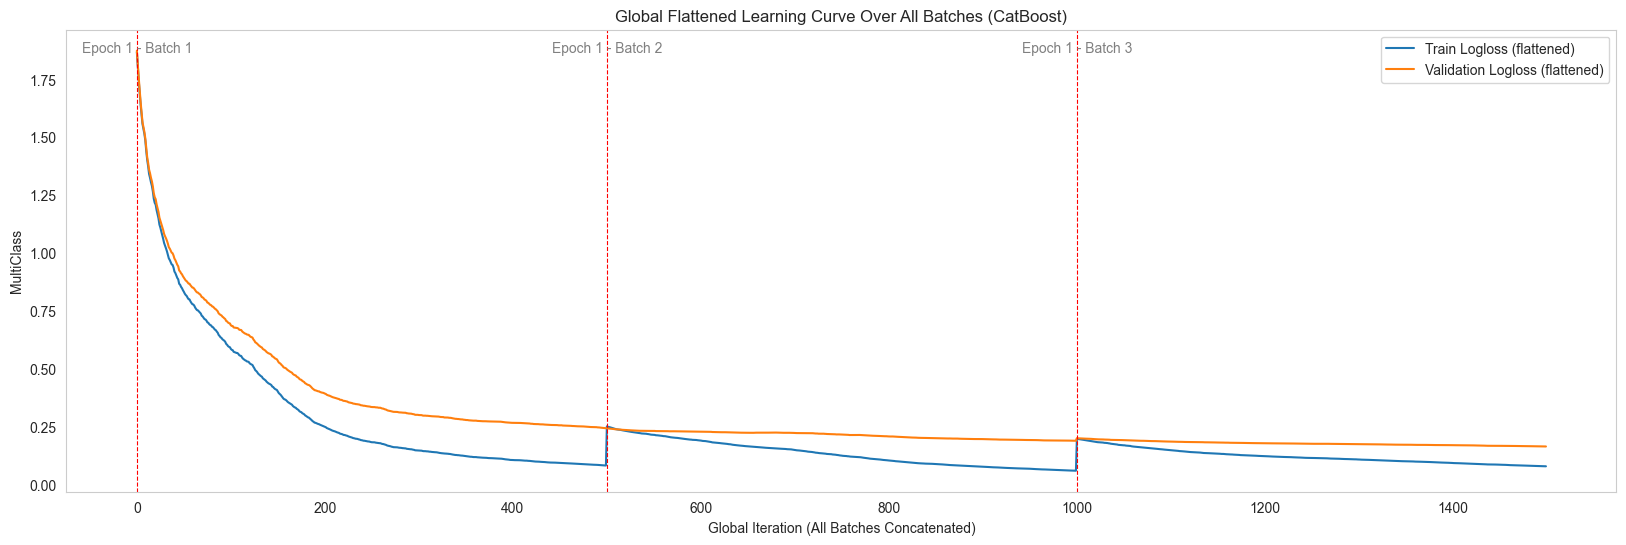

2025-09-26 10:46:53,559 - spark_batch_trainer.core.base_trainer - INFO - Learning curve plotted successfully.
2025-09-26 10:46:53,560 - spark_batch_trainer.core.base_trainer - INFO - CatBoost training completed successfully
2025-09-26 10:46:53,560 - spark_batch_trainer.core.base_trainer - INFO - Total batches processed: 3
2025-09-26 10:46:53,560 - spark_batch_trainer.core.base_trainer - INFO - Best validation loss: 0.16354
2025-09-26 10:46:53,561 - spark_batch_trainer.core.base_trainer - INFO - Final model selected: best
2025-09-26 10:46:53,561 - spark_batch_trainer.core.base_trainer - INFO - 🔖 Categorical features used: 8



   Evaluating the Trained Model



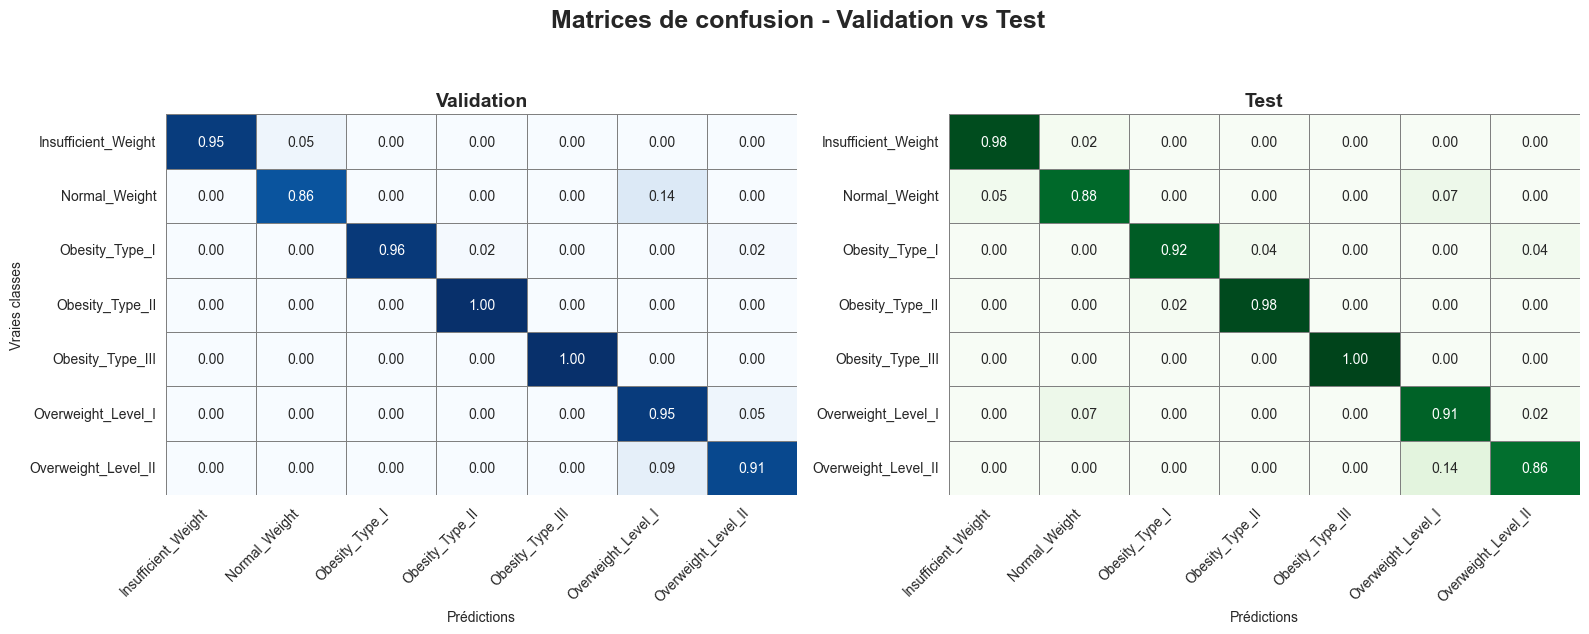

In [5]:
# ==================================================
# 1. Chargement & Configuration
# ==================================================
print("Load Big MultiClass Dataset (Diabetes)")

target_column = "NObeyesdad"

# Configuration modèle CatBoost (classification multiclasse)
config_model = {
    "loss_function": "MultiClass",     # Classification multiclasse
    "eval_metric": "MultiClass",       # Logloss multiclass
    "iterations": 500,                 # Nombre d'itérations
    "learning_rate": 0.05,             # Taux d’apprentissage
    "depth": 6,                        # Profondeur des arbres
    "l2_leaf_reg": 3.0,                # Régularisation L2
    "auto_class_weights": "Balanced",  # Poids auto si dataset déséquilibré
    "bootstrap_type": "Bernoulli",     # Sous-échantillonnage aléatoire
    "subsample": 0.8,                  # Ratio de données par arbre
    "random_seed": 42,                 # Reproductibilité
    "verbose": 100,                    # Logs toutes les 100 itérations
    # "early_stopping_rounds": 50,     # Peut être géré dans .fit(valid_set=...)
}

# Configuration entraînement batch-wise
config_training = {
    "num_batches": 3,              # Nombre de lots pour l'entraînement
    "max_patience": 2,             # Patience pour early stopping global
    "show_learning_curve": True,   # Afficher la courbe d'apprentissage
}

print("===== Configuration CatBoost =====")
pprint.pprint(config_model, sort_dicts=False)
print("=================================\n")

print("===== Configuration Training =====")
pprint.pprint(config_training, sort_dicts=False)
print("=================================\n")


# ==================================================
# 2. Instanciation & Entraînement
# ==================================================
print("Instantiating CatBoostTrainer...")
trainer = CatBoostTrainer()

print("Applying fit method...")
trainer.fit(
    train_dataframe=spark_train_df,
    valid_dataframe=spark_valid_df,
    target_column=target_column,
    config_training=config_training,
    config_model=config_model,
)


# ==================================================
# 3. Évaluation du modèle
# ==================================================
print("\n" + "="*40)
print("   Evaluating the Trained Model")
print("="*40 + "\n")

# Récupération du modèle entraîné
final_model = trainer.get_trained_model()

# Prédictions
y_pred_valid = final_model.predict(X_valid)
y_pred_test  = final_model.predict(X_test)

# --------------------------------------------------
# Matrices de confusion
# --------------------------------------------------
plot_confusion_matrices(
    y_true_valid=y_valid,
    y_pred_valid=y_pred_valid,
    y_true_test=y_test,
    y_pred_test=y_pred_test,
    class_names=encoder.classes_,
    normalize=True   # Normaliser pour afficher en %
)

# --------------------------------------------------
# Probabilités & Confiance
# --------------------------------------------------
y_proba_valid = final_model.predict_proba(X_valid)
y_proba_test  = final_model.predict_proba(X_test)

# Histogramme des probabilités maximales
plot_max_proba_distribution_px(y_proba_valid, y_proba_test)

# Violin plot par classe
plot_classwise_confidence_px(
    y_proba_valid,
    y_proba_test,
    class_names=encoder.classes_
)

# Courbe de calibration
plot_calibration_curve_px(
    y_valid, y_proba_valid,
    y_test, y_proba_test
)


## 3. Model - LGBMClassifier

2025-09-26 10:47:39,901 - spark_batch_trainer.core.base_trainer - INFO - Validating input parameters...
2025-09-26 10:47:39,904 - spark_batch_trainer.core.base_trainer - INFO - Input parameters validation passed.
2025-09-26 10:47:39,905 - spark_batch_trainer.core.base_trainer - INFO - Preparing validation data...
2025-09-26 10:47:39,905 - spark_batch_trainer.core.base_trainer - INFO - Converting Spark DataFrame to pandas DataFrame for validation.


Loading LightGBMTrainer module...
LightGBMTrainer instantiated successfully
===== Configuration LGBM =====
{'objective': 'multiclass',
 'metric': 'multi_logloss',
 'num_class': 7,
 'n_estimators': 500,
 'num_leaves': 31,
 'learning_rate': 0.05,
 'max_depth': -1,
 'reg_lambda': 1.0,
 'subsample': 0.8,
 'colsample_bytree': 0.8,
 'random_state': 42,
 'force_col_wise': True,
 'verbose': -1}

===== Configuration Training =====
{'num_batches': 5,
 'max_patience': 2,
 'show_learning_curve': True,
 'use_sample_weight': True,
 'eval_metric': 'multi_logloss'}

===== Configuration LR Scheduler =====
{'initial_lr': 0.1, 'decay_rate': 0.25, 'min_lr': 0.001}

Applying fit method...


2025-09-26 10:47:40,460 - spark_batch_trainer.core.base_trainer - INFO - Categorical features detected in validation set
2025-09-26 10:47:40,461 - spark_batch_trainer.core.base_trainer - INFO - Number of categorical features identified: 8
2025-09-26 10:47:40,462 - spark_batch_trainer.core.base_trainer - INFO - Sample weights for validation set computed successfully
2025-09-26 10:47:40,463 - spark_batch_trainer.core.memory_optimizer - INFO - === Starting memory optimization ===
2025-09-26 10:47:40,466 - spark_batch_trainer.core.memory_optimizer - INFO - Shape before optimization: (317, 16)
2025-09-26 10:47:40,467 - spark_batch_trainer.core.memory_optimizer - INFO - Shape after optimization:  (317, 16)
2025-09-26 10:47:40,468 - spark_batch_trainer.core.memory_optimizer - INFO - Memory before: 0.02 MB
2025-09-26 10:47:40,468 - spark_batch_trainer.core.memory_optimizer - INFO - Memory after:  0.01 MB
2025-09-26 10:47:40,469 - spark_batch_trainer.core.memory_optimizer - INFO - Memory reduce

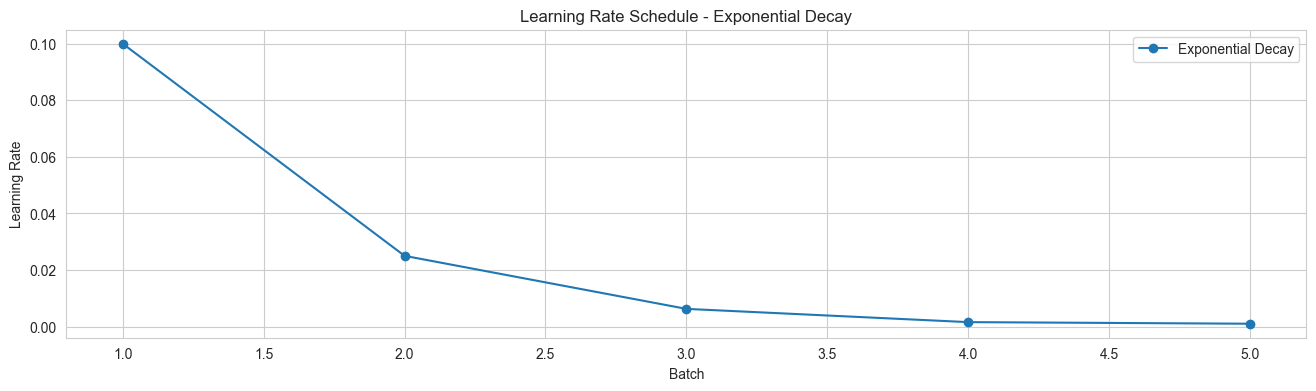

2025-09-26 10:48:03,348 - spark_batch_trainer.core.base_trainer - INFO - Plotting learning curve of LGBM model...


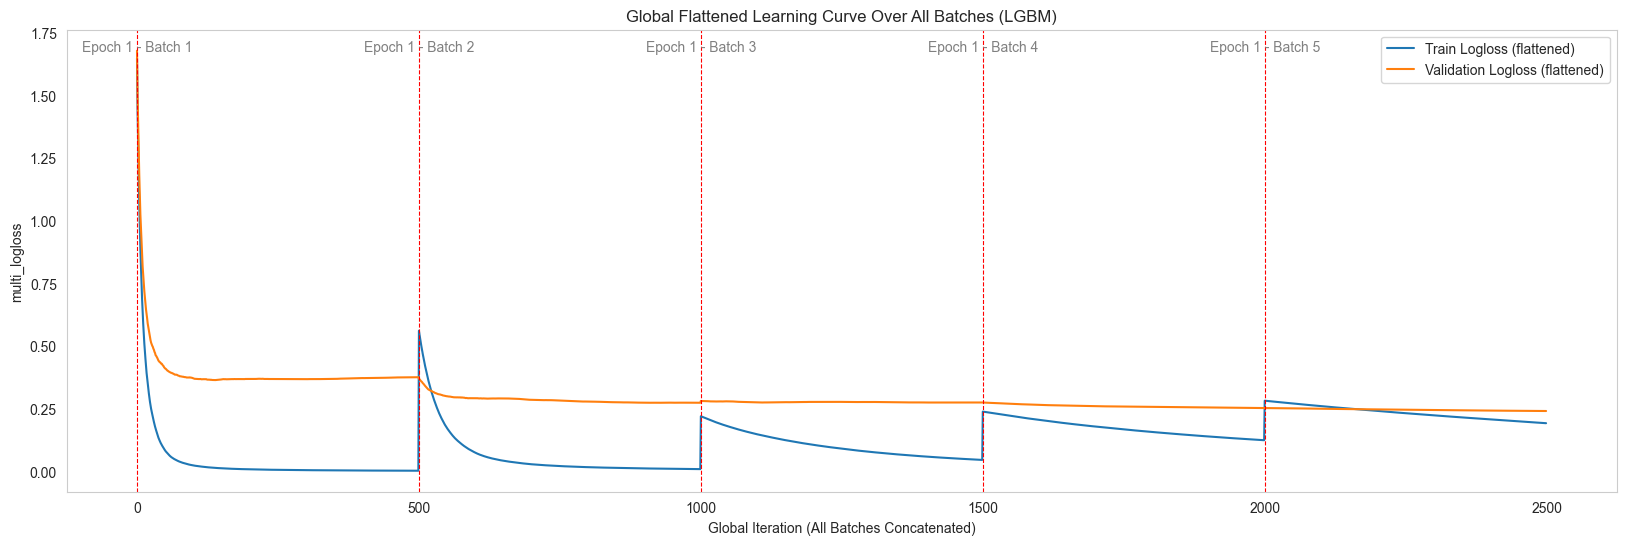

2025-09-26 10:48:03,485 - spark_batch_trainer.core.base_trainer - INFO - Learning curve plotted successfully.
2025-09-26 10:48:03,486 - spark_batch_trainer.core.base_trainer - INFO - LGBM training completed successfully
2025-09-26 10:48:03,486 - spark_batch_trainer.core.base_trainer - INFO - Total batches processed: 5
2025-09-26 10:48:03,487 - spark_batch_trainer.core.base_trainer - INFO - Best validation loss: 0.24103
2025-09-26 10:48:03,488 - spark_batch_trainer.core.base_trainer - INFO - Final model selected: best
2025-09-26 10:48:03,488 - spark_batch_trainer.core.base_trainer - INFO - Categorical features used: 8



   Evaluating the Trained Model



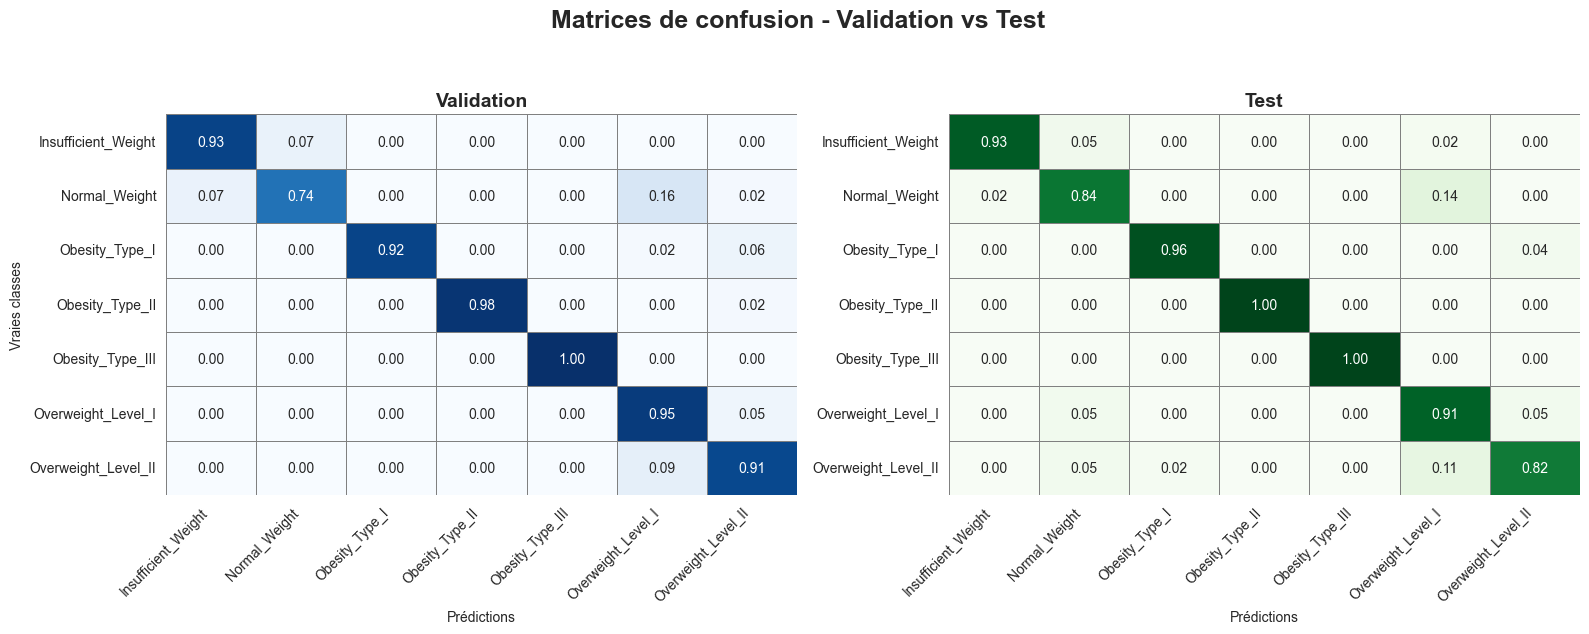

In [6]:
# ==================================================
# 1. Chargement & Configuration
# ==================================================
print("Loading LightGBMTrainer module...")
trainer = LightGBMTrainer()  # Wrapper LightGBM LGBMClassifier
print("LightGBMTrainer instantiated successfully")

target_column = "NObeyesdad"

# Configuration modèle LightGBM (classification multiclasse)
config_model = {
    "objective": "multiclass",         # Classification multiclasse
    "metric": "multi_logloss",         # Métrique multiclass
    "num_class": len(encoder.classes_),# Nombre de classes dynamiquement
    "n_estimators": 500,               # Nombre d’arbres
    "num_leaves": 31,                  # Feuilles max par arbre
    "learning_rate": 0.05,             # Taux d’apprentissage
    "max_depth": -1,                   # -1 = pas de limite → LightGBM choisit
    "reg_lambda": 1.0,                 # Régularisation L2
    "subsample": 0.8,                  # Sous-échantillonnage données
    "colsample_bytree": 0.8,           # Sous-échantillonnage features
    "random_state": 42,                # Reproductibilité
    "force_col_wise": True,            # Optimisation mémoire
    # "early_stopping_rounds": 50,     # Peut être géré dans .fit(valid_set=...)
    "verbose": -1,
}

# Configuration scheduler du learning rate
config_lr_scheduler = {
    "initial_lr": 0.1,
    "decay_rate": 0.25,
    "min_lr": 1e-3,
}

# Configuration entraînement batch-wise
config_training = {
    "num_batches": 5,                # Nombre de lots
    "max_patience": 2,               # Patience early stopping global
    "show_learning_curve": True,     # Courbe d’apprentissage
    "use_sample_weight": True,       # Prendre en compte pondérations
    "eval_metric": "multi_logloss",  # Cohérent avec multiclass
}

print("===== Configuration LGBM =====")
pprint.pprint(config_model, sort_dicts=False)
print("=================================\n")

print("===== Configuration Training =====")
pprint.pprint(config_training, sort_dicts=False)
print("=================================\n")

print("===== Configuration LR Scheduler =====")
pprint.pprint(config_lr_scheduler, sort_dicts=False)
print("=================================\n")


# ==================================================
# 2. Entraînement
# ==================================================
print("Applying fit method...")
trainer.fit(
    train_dataframe=spark_train_df,
    valid_dataframe=spark_valid_df,
    target_column=target_column,
    config_training=config_training,
    config_model=config_model,
    config_lr_scheduler=config_lr_scheduler,
)


# ==================================================
# 3. Évaluation
# ==================================================
print("\n" + "="*40)
print("   Evaluating the Trained Model")
print("="*40 + "\n")

# Récupération du modèle entraîné
final_model = trainer.get_trained_model()

# Prédictions
y_pred_valid = final_model.predict(X_valid)
y_pred_test  = final_model.predict(X_test)

# --------------------------------------------------
# Matrices de confusion
# --------------------------------------------------
plot_confusion_matrices(
    y_true_valid=y_valid,
    y_pred_valid=y_pred_valid,
    y_true_test=y_test,
    y_pred_test=y_pred_test,
    class_names=encoder.classes_,
    normalize=True   # Normaliser pour % lecture
)

# --------------------------------------------------
# Probabilités & Confiance
# --------------------------------------------------
y_proba_valid = final_model.predict_proba(X_valid)
y_proba_test  = final_model.predict_proba(X_test)

# Histogramme des probabilités maximales
plot_max_proba_distribution_px(y_proba_valid, y_proba_test)

# Violin plot par classe
plot_classwise_confidence_px(
    y_proba_valid,
    y_proba_test,
    class_names=encoder.classes_
)

# Courbe de calibration
plot_calibration_curve_px(
    y_valid, y_proba_valid,
    y_test, y_proba_test
)


In [10]:
# Récupérer la session Spark active
spark = spark_train_df.sparkSession

# Stopper Spark
stop_spark_session(spark)


[SPARK] Stopping Spark session...
[SPARK] Session stopped successfully.
